# Multiple regression: more features, more information?

<a target="_blank" href="https://colab.research.google.com/github/changyaochen/MECE4520/blob/master/site/regression/04-multiple-linear-regression.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Ambient temperature explains some of the variation in turbine NOx, but substantial residual remains, and the R-squared is relatively low. 
Can another measurement (i.e., feature) help? Namely, what if we move beyond simple linear regression and consider models with more than one feature?

We will compare three models on the same observations:

1. Ambient temperature (**AT**).
2. AT and compressor discharge pressure (**CDP**).
3. AT, CDP, and turbine energy yield (**TEY**).

**Learning objectives**

- Fit a linear model with more than one feature.
- Interpret a coefficient while holding the other included features fixed.
- Distinguish a better fit to the observed data from better predictions for new observations.
- Recognize how multicollinearity makes individual coefficients less precise.
- Explain why an existing coefficient can change sign after adding a feature.


## 1. Load the measurements

Just a reminder of the data structure: each row is an hourly aggregate from the course gas-turbine dataset.

| Column | Meaning | Units |
|---|---|---|
| AT | Ambient temperature | °C |
| CDP | Compressor discharge pressure | mbar |
| TEY | Turbine energy yield | MWh |
| NOX | Nitrogen-oxides concentration in the exhaust | mg/m³ |

Use the same rows for every model so that changes in $R^2$ reflect the features, not a change in observations.


In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import norm

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"font.size": 12})

# Prefer the local CSV; download it when running independently in Colab.
DATA_URL = "https://raw.githubusercontent.com/changyaochen/MECE4520/master/site/data/gas-turbine-course.csv"
candidates = [
    Path("../data/gas-turbine-course.csv"),
    Path("site/data/gas-turbine-course.csv"),
    Path("gas-turbine-course.csv"),
]
data_path = next((path for path in candidates if path.exists()), candidates[-1])
if not data_path.exists():
    urlretrieve(DATA_URL, data_path)

data = pd.read_csv(data_path)
regression_data = data[["AT", "CDP", "TEY", "NOX"]].dropna()
y = regression_data["NOX"]
print(f"Observations shared by all three models: {len(regression_data):,}")
regression_data.head()


Observations shared by all three models: 36,733


,AT,CDP,TEY,NOX
0,4.5878,11.898,134.67,81.952
1,4.2932,11.892,134.67,82.377
2,3.9045,12.042,135.10,83.776
3,3.7436,11.990,135.03,82.505
4,3.7516,11.910,134.67,82.028


## 2. Look at an additional feature

CDP records an operating condition that AT alone does not describe. Before fitting, look at its relationship with NOx and with AT.

A useful additional feature explains variation in the response beyond what the existing features capture. Low correlation with AT alone does not guarantee that CDP will help.


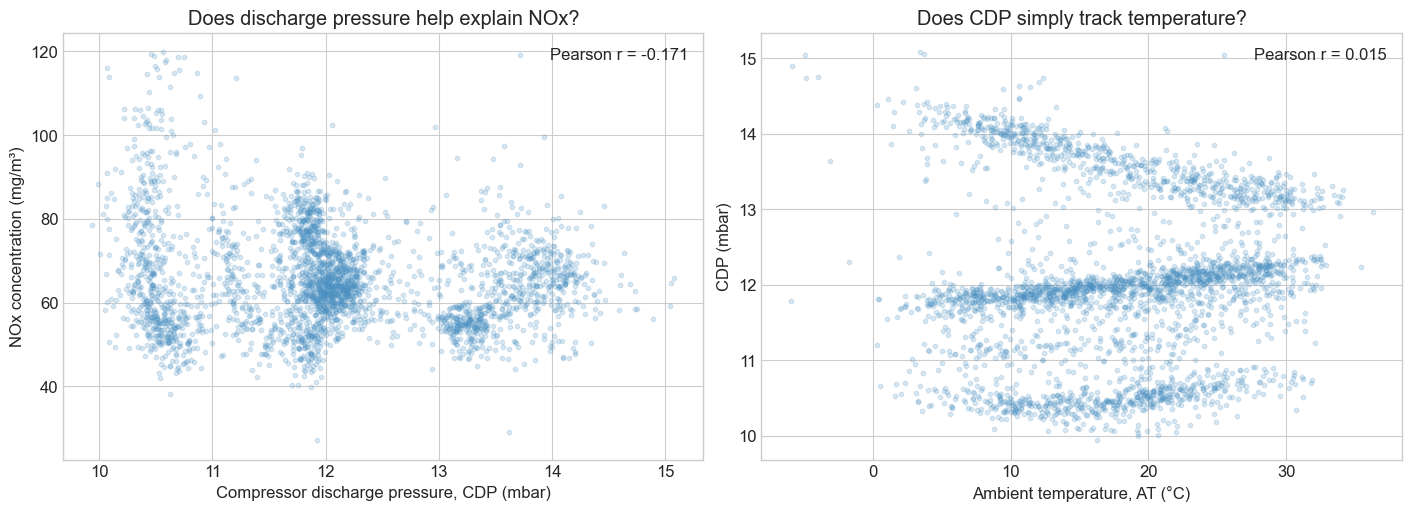

Correlation between AT and CDP: 0.015


In [2]:
# Subsample only for plotting; all model fits below use every available row.
plot_data = regression_data.sample(n=min(3000, len(regression_data)), random_state=4520)
# Calculate Pearson correlations using all rows, not just the plotted sample.
r_cdp_nox = regression_data["CDP"].corr(regression_data["NOX"])
r_at_cdp = regression_data["AT"].corr(regression_data["CDP"])
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].scatter(plot_data["CDP"], plot_data["NOX"], s=10, alpha=0.2, color="#4a90c2",
                label=f"Pearson r = {r_cdp_nox:.3f}")
axes[0].set(xlabel="Compressor discharge pressure, CDP (mbar)",
            ylabel="NOx concentration (mg/m³)", title="Does discharge pressure help explain NOx?")
axes[0].legend()
axes[1].scatter(plot_data["AT"], plot_data["CDP"], s=10, alpha=0.2, color="#4a90c2",
                label=f"Pearson r = {r_at_cdp:.3f}")
axes[1].set(xlabel="Ambient temperature, AT (°C)",
            ylabel="CDP (mbar)", title="Does CDP simply track temperature?")
axes[1].legend()
plt.show()

print(f"Correlation between AT and CDP: {regression_data['AT'].corr(regression_data['CDP']):.3f}")


AT and CDP have very little **linear correlation** in these data. This does not establish statistical independence.

## 3. Fit a multiple linear regression

Extend the population model by adding a second feature:

$$
\mathrm{NOx}_i = \beta_0 + \beta_1\mathrm{AT}_i
+ \beta_2\mathrm{CDP}_i + \varepsilon_i.
$$

Least squares still chooses the coefficients to minimize the sum of squared residuals. The fitted prediction is now

$$
\widehat{\mathrm{NOx}}_i = \hat\beta_0 + \hat\beta_1\mathrm{AT}_i
+ \hat\beta_2\mathrm{CDP}_i.
$$

The interpretation changes: $\beta_2$ is the difference in the model's mean NOx associated with a one-mbar increase in CDP **holding AT fixed**. Similarly, $\beta_1$ describes the temperature relationship holding CDP fixed.

These are conditional associations, not claims about what would happen under an intervention.


In [3]:
# Passing two feature columns fits both coefficients jointly.
model_at = sm.OLS(y, sm.add_constant(regression_data[["AT"]])).fit()
model_at_cdp = sm.OLS(y, sm.add_constant(regression_data[["AT", "CDP"]])).fit()

pd.DataFrame({
    "AT only": model_at.params,
    "AT + CDP": model_at_cdp.params,
}).rename(index={"const": "Intercept"}).round(4)


,AT only,AT + CDP
AT,-0.8753,-0.8714
CDP,NaN,-1.7458
Intercept,80.7965,101.7823


### Read the `statsmodels` summary

`statsmodels` provides a compact summary of the fitted model. The coefficient table is the most useful part for now: `coef` gives each fitted coefficient, `std err` gives its standard error, `t` standardizes the coefficient relative to zero, and `P>|t|` gives the corresponding two-sided p-value. The summary uses the finite-sample $t$ reference; with this many observations, its p-values are effectively the same as the Normal approximation used earlier. `[0.025, 0.975]` gives the limits of a 95% confidence interval. `R-squared` near the top summarizes fit to these observed data.

The notebook will return to these quantities individually. The other diagnostics in this output will make more sense after we discuss model checking and prediction.


In [4]:
model_at_cdp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    NOX   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     9378.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:34:29   Log-Likelihood:            -1.3482e+05
No. Observations:               36733   AIC:                         2.697e+05
Df Residuals:                   36730   BIC:                         2.697e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        101.7823      0.562    181.051      0.000     100.680     102.884
AT            -0.8714      0.007   -130.880      0.000      -0.884      -0.858
CDP           -1.7458      0.046    -38.335      0.000      -1.835      -1.657
==============================================================================
Omnibus:                     4049.812   Durbin-Watson:                   0.299
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             7641.973
Skew:                           0.731   Prob(JB):                         0.00
Kurtosis:                       4.689   Cond. No.                         254.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The missing entry in the AT-only column means that model does not include CDP.

### Does the fit improve?

Compare $R^2$ on the same data used to fit the models:


In [5]:
fit_comparison = pd.DataFrame({
    "Features": ["AT", "AT + CDP"],
    "R²": [model_at.rsquared, model_at_cdp.rsquared],
})
fit_comparison


,Features,R²
0,AT,0.311558
1,AT + CDP,0.338043


$R^2$ increases from about **0.312 to 0.338**. The improvement is modest, but CDP adds information beyond AT.

## 4. Could energy yield help too?

Turbine energy yield, TEY, measures the energy produced during an operating hour. Before adding it to the model, examine its raw relationship with NOx.


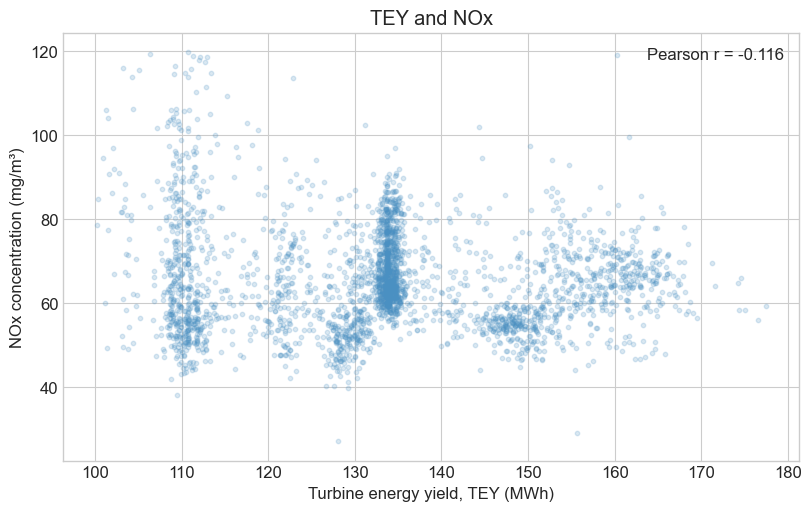

In [6]:
# Pearson's r summarizes the raw linear association, using all observations.
r_tey_nox = regression_data["TEY"].corr(regression_data["NOX"])

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.scatter(plot_data["TEY"], plot_data["NOX"], s=10, alpha=0.2, color="#4a90c2",
           label=f"Pearson r = {r_tey_nox:.3f}")
ax.set(xlabel="Turbine energy yield, TEY (MWh)",
       ylabel="NOx concentration (mg/m³)", title="TEY and NOx")
ax.legend()
plt.show()


The raw correlation is negative but weak. It gives us a reason to explore TEY, without establishing whether it adds useful information beyond AT and CDP.

Add TEY to the model, then inspect the full summary. Compare the existing **CDP coefficient** with its value in the two-feature model.


In [7]:
# Add just one feature: TEY. Keep exactly the same observations.
model_all = sm.OLS(
    y, sm.add_constant(regression_data[["AT", "CDP", "TEY"]])
).fit()
display(model_all.summary())

pd.DataFrame({
    "Features": ["AT", "AT + CDP", "AT + CDP + TEY"],
    "R²": [model_at.rsquared, model_at_cdp.rsquared, model_all.rsquared],
}).round(4)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    NOX   R-squared:                       0.341
Model:                            OLS   Adj. R-squared:                  0.341
Method:                 Least Squares   F-statistic:                     6339.
Date:                Sun, 20 Sep 2026   Prob (F-statistic):               0.00
Time:                        20:34:29   Log-Likelihood:            -1.3474e+05
No. Observations:               36733   AIC:                         2.695e+05
Df Residuals:                   36729   BIC:                         2.695e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         88.3459      1.166     75.766      0.000      86.060      90.631
AT            -0.9597      0.009   -101.545      0.000      -0.978      -0.941
CDP            3.8867      0.431      9.019      0.000       3.042       4.731
TEY           -0.3965      0.030    -13.144      0.000      -0.456      -0.337
==============================================================================
Omnibus:                     3047.104   Durbin-Watson:                   0.292
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             5096.065
Skew:                           0.618   Prob(JB):                         0.00
Kurtosis:                       4.342   Cond. No.                     3.39e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.39e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

,Features,R²
0,AT,0.3116
1,AT + CDP,0.3380
2,AT + CDP + TEY,0.3411


Adding TEY raises $R^2$ only slightly, from about **0.3380 to 0.3411**. But the existing CDP coefficient changes from **−1.7458 to +3.8867**, and it remains statistically significant.

We improved the overall fit, yet the fitted CDP relationship changed direction. What changed when we added TEY? 
Before interpreting the new coefficient, let's examine how these two features relate to each other.

## 5. The missing context: CDP and TEY


Before focusing on CDP and TEY, inspect the relationships among all available feature measurements. The heatmap excludes NOx, our response, and `campaign_year`, a collection-year label.

Each cell shows a Pearson correlation. Values near +1 or −1 indicate a strong linear relationship; values near zero indicate little linear correlation, which does not establish independence. Look for groups of features that move together.

The additional measurements are AP (ambient pressure), AH (ambient humidity), AFDP (air-filter differential pressure), GTEP (gas-turbine exhaust pressure), TIT (turbine inlet temperature), TAT (turbine-after temperature), and CO (carbon monoxide concentration). CO is another measured emission; using it for prediction would require it to be available when the prediction is made.


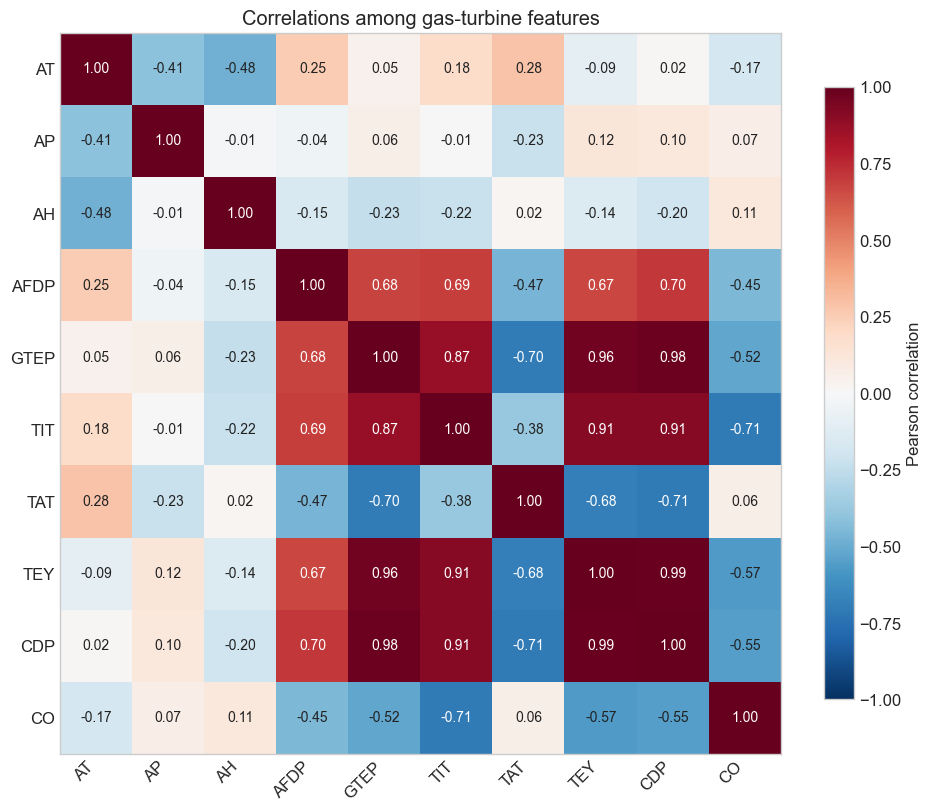

In [8]:
# Use all feature measurements, excluding the response and collection-year label.
feature_columns = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP", "CO"]
# pandas computes each correlation from rows where both measurements are present.
# Some features have missing values, so cell pairs may use different row counts.
feature_correlations = data[feature_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True)
# Fix the scale so that equal colors always represent equal correlations.
heatmap = ax.imshow(feature_correlations, cmap="RdBu_r", vmin=-1, vmax=1,
                    interpolation="nearest")
ax.set_xticks(np.arange(len(feature_columns)), labels=feature_columns, rotation=45, ha="right")
ax.set_yticks(np.arange(len(feature_columns)), labels=feature_columns)
# Disable the inherited whitegrid style so gridlines do not cross the cells.
ax.grid(False)

# Annotate every cell; use white text on the darkest colors for readability.
for row in range(len(feature_columns)):
    for col in range(len(feature_columns)):
        correlation = feature_correlations.iloc[row, col]
        ax.text(col, row, f"{correlation:.2f}", ha="center", va="center",
                color="white" if abs(correlation) >= 0.6 else "#222222", fontsize=10)

fig.colorbar(heatmap, ax=ax, label="Pearson correlation", shrink=0.85)
ax.set_title("Correlations among gas-turbine features")
plt.show()


CDP and TEY stand out with a correlation near +1. GTEP also overlaps strongly with both. A heatmap flags these relationships; the scatterplot below shows the shape of the CDP–TEY relationship in more detail.


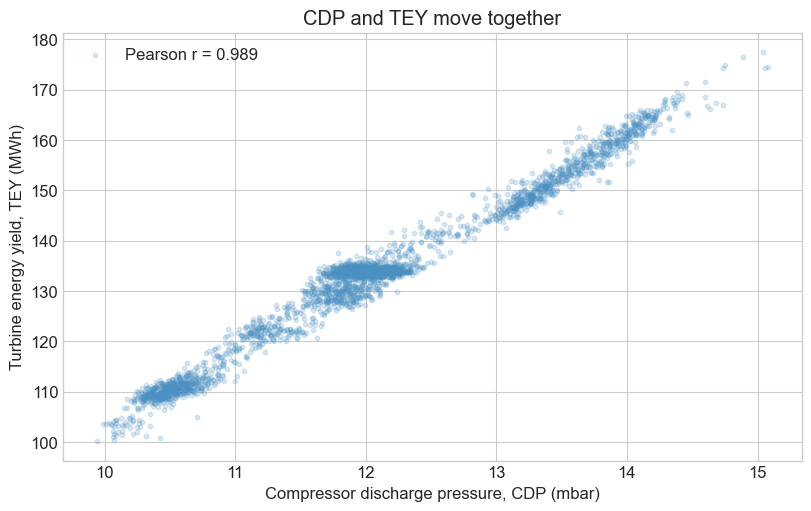

In [9]:
# Reveal the overlap only after inspecting the expanded model.
r_cdp_tey = regression_data["CDP"].corr(regression_data["TEY"])
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
ax.scatter(plot_data["CDP"], plot_data["TEY"], s=10, alpha=0.2, color="#4a90c2",
           label=f"Pearson r = {r_cdp_tey:.3f}")
ax.set(xlabel="Compressor discharge pressure, CDP (mbar)",
       ylabel="Turbine energy yield, TEY (MWh)",
       title="CDP and TEY move together")
ax.legend()
plt.show()


The correlation is about **0.989**. CDP and TEY move together so closely that the data contain relatively little variation in one while the other remains fixed.

This strong linear dependence among features is called **multicollinearity**. Here we can still fit the model, but separating the individual feature coefficients becomes much less precise.


## 6. A practical workflow for adding features

Adding CDP improved fit to the observed data. Adding TEY improved fit only slightly and reversed the existing CDP coefficient. Use this sequence of checks when building your own model:

1. **Explore each feature against the response.** Use scatterplots and correlation coefficients. Start with a physically meaningful feature showing a clear relationship. If ranking correlations, compare their absolute values; a strong negative correlation can be just as useful as a strong positive one.
2. **Inspect relationships among features.** Use a correlation heatmap to identify overlapping information, then inspect relevant scatterplots. High correlation calls for closer inspection, rather than automatic removal.
3. **Fit a model and examine its residuals against candidate features.** A remaining pattern suggests information the current model misses. The next feature need not be the one with the next-largest raw correlation with the response.
4. **Add one feature and reassess.** Compare $R^2$, residual patterns, and the existing coefficients' signs and standard errors. Investigate large changes and state what each coefficient now holds fixed before interpreting it physically.

This is an exploratory workflow, not a guarantee of finding the best model. Pairwise correlations can miss nonlinear relationships and dependencies involving several features. Also, adding a feature cannot decrease ordinary $R^2$ when nested least-squares models use the same observations; better fit alone does not guarantee better predictions for new observations.

A significant coefficient is conditional on its model. Removing a correlated feature changes that model again and does not automatically produce the correct physical interpretation.

### Try it

Fit AT + TEY without CDP. Compare its $R^2$ and TEY coefficient with the full model. Does removing CDP change the question the TEY coefficient answers?


In [10]:
# Uncomment to compare a different two-feature model.
# model_at_tey = sm.OLS(
#     y, sm.add_constant(regression_data[["AT", "TEY"]])
# ).fit()
# print("R²:", model_at_tey.rsquared)
# print("TEY coefficient:", model_at_tey.params["TEY"])
# print("TEY standard error:", model_at_tey.bse["TEY"])


## Check-in

1. What does “holding the other features fixed” mean for the CDP coefficient?
2. Why does a higher $R^2$ on the observed data not guarantee better predictions for new observations?
3. Why does a close relationship between CDP and TEY inflate coefficient uncertainty?
4. Can a coefficient be statistically significant even after its sign changes when another feature is added?

[Return to the Regression page](index.qmd)
